In [ ]:
# ============= 1. إنشاء env و تثبيت المكتبات =============

import os
import subprocess
import sys



env_name = "env-flan-t5"
print(f"🔧 جاري إنشاء البيئة الافتراضية '{env_name}'...")


subprocess.check_call([sys.executable, "-m", "venv", env_name])



if os.name == 'nt':  # Windows
    pip_path = os.path.join(env_name, "Scripts", "pip.exe")
else:  # Unix/Linux
    pip_path = os.path.join(env_name, "bin", "pip")



requirements_file = "requirements-flan-t5.txt"

subprocess.check_call([pip_path, "install", "-r", requirements_file])





In [7]:
import pandas as pd
import torch
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
)


In [8]:
# ============= 1. تقسيم البيانات =============
from sklearn.model_selection import train_test_split


dataset = pd.read_csv("conversations.csv")

dataset = dataset[:100]

print("✂️ جاري تقسيم البيانات...")
train_df, eval_df = train_test_split(
    dataset,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

print(f"📈 حجم البيانات: التدريب = {len(train_dataset)}، التقييم = {len(eval_dataset)}")


✂️ جاري تقسيم البيانات...
📈 حجم البيانات: التدريب = 90، التقييم = 10


In [5]:

# ============= 2. تحميل النموذج والTokenizer =============
print("🤖 جاري تحميل النموذج...")
MODEL_NAME = "google/flan-t5-small"  # حجم أكبر من small لأداء أفضل

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    force_download=True,  # إجبار التحميل من جديد
    resume_download=True,  # استئناف التحميل إذا كان هناك انقطاع
    local_files_only=False  # لا تعتمد على الملفات المحلية فقط
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    force_download=True,
    resume_download=True,
    local_files_only=False
)
    


# إضافة رموز خاصة للمحادثة
special_tokens = ["<system>", "<user>", "<assistant>"]
tokenizer.add_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))


🤖 جاري تحميل النموذج...


c:\Users\IFIX\Documents\university\مشروع تخرج\coding-articture\env-flan-t5\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Error while downloading from https://huggingface.co/google/flan-t5-small/resolve/main/model.safetensors: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume

Embedding(32103, 512)

In [9]:
# ============= 3. Tokenization مع طول أقل =============
def preprocess_function(examples, max_length=256):
    inputs = examples["input_text"]
    targets = examples["target_text"]

    model_inputs = tokenizer(
        inputs,
        max_length=max_length,
        truncation=True,
        padding="max_length",
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,
            max_length=128,
            truncation=True,
            padding="max_length",
        )

    model_inputs["labels"] = labels["input_ids"]
    
    # تحويل -100 لـ pad_token_id في labels
    model_inputs["labels"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in model_inputs["labels"]
    ]
    
    return model_inputs




print("🔤 جاري معالجة النصوص...")
train_tokenized = train_dataset.map(
    preprocess_function,
    batched=True,
     batch_size=500,  # ⭐ تقليل حجم الدفعة
    remove_columns=train_dataset.column_names
)

eval_tokenized = eval_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=200,  # ⭐ تقليل حجم الدفعة
    remove_columns=eval_dataset.column_names
)

🔤 جاري معالجة النصوص...


Map:   0%|          | 0/90 [00:00<?, ? examples/s]c:\Users\IFIX\Documents\university\مشروع تخرج\coding-articture\env-flan-t5\lib\site-packages\transformers\tokenization_utils_base.py:3860: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 10/10 [00:00<00:00, 476.18 examples/s]


In [10]:
# ============= 9. إعداد معايير التدريب =============
# ============= باختصار =============
print("🤖 جاري تحميل النموذج...")
MODEL_NAME = "google/flan-t5-small"  # حجم أكبر من small لأداء أفضل

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    force_download=True,  # إجبار التحميل من جديد
    resume_download=True,  # استئناف التحميل إذا كان هناك انقطاع
    local_files_only=False  # لا تعتمد على الملفات المحلية فقط
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    force_download=True,
    resume_download=True,
    local_files_only=False
)
    


# إضافة رموز خاصة للمحادثة
special_tokens = ["<system>", "<user>", "<assistant>"]
tokenizer.add_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))


🤖 جاري تحميل النموذج...


c:\Users\IFIX\Documents\university\مشروع تخرج\coding-articture\env-flan-t5\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Embedding(32103, 512)

In [11]:
# ============= 10. إعداد Data Collator =============
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)



In [12]:
print("⚙️  إعداد التدريب...")

training_args = TrainingArguments(
    output_dir="./nutrition_chatbot_v2",
    evaluation_strategy="steps",  # تغيير إلى steps ليطابق save_strategy
    eval_steps=500,  # تقييم كل 500 خطوة
    learning_rate=2e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=1,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    logging_dir="./logs",
    save_strategy="steps",  # حفظ checkpoints كل عدد من الخطوات
    save_steps=500,  # حفظ كل 500 خطوة
    save_total_limit=3,  # الاحتفاظ بآخر 3 checkpoints فقط
    load_best_model_at_end=True,
    metric_for_best_model="eval_rouge1",
    fp16=torch.cuda.is_available(),  # هنا نختبر GPU مباشرة
    dataloader_num_workers=0,
)

⚙️  إعداد التدريب...


In [13]:
import nltk
nltk.download("punkt")


[nltk_data] Downloading package punkt to C:\Users\IFIX/nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [14]:
import evaluate

rouge = evaluate.load("rouge")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics_safe(eval_pred):
    """
    دالة آمنة لحساب المقاييس
    """
    try:
        predictions, labels = eval_pred
        
        # معالجة predictions
        if isinstance(predictions, tuple):
            predictions = predictions[0]
        
        # تحويل logits إلى token IDs
        if predictions.ndim == 3:
            predictions = np.argmax(predictions, axis=-1)
        
        # فك ترميز
        decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        
        # استبدال -100 في labels
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        
        # تصفية النصوص الفارغة
        filtered_preds = []
        filtered_labels = []
        
        for pred, label in zip(decoded_preds, decoded_labels):
            if pred.strip() and label.strip():  # فقط النصوص غير الفارغة
                filtered_preds.append(pred)
                filtered_labels.append(label)
        
        if not filtered_preds or not filtered_labels:
            print("⚠️ تحذير: لا توجد نصوص صالحة للحساب")
            return {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0, "accuracy": 0.0}
        
        # حساب ROUGE
        rouge_result = rouge.compute(
            predictions=filtered_preds,
            references=filtered_labels,
            use_stemmer=True
        )
        
        # حساب الدقة النصية (accuracy) باستخدام المترجم القياسي
        acc_result = accuracy_metric.compute(
            predictions=filtered_preds,
            references=filtered_labels
        )
        
        return {
            "rouge1": round(rouge_result["rouge1"], 4),
            "rouge2": round(rouge_result["rouge2"], 4),
            "rougeL": round(rouge_result["rougeL"], 4),
            "accuracy": round(acc_result["accuracy"], 4)
        }
        
    except Exception as e:
        print(f"⚠️ خطأ في compute_metrics: {e}")
        return {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0, "accuracy": 0.0}

In [16]:
# ============= 11.5 التحقق من البيانات =============
# فحص عينة من البيانات
sample = train_tokenized[0]
print("🔍 فحص عينة من البيانات:")
print(f"   keys: {sample.keys()}")
print(f"   input_ids length: {len(sample['input_ids'])}")
print(f"   attention_mask length: {len(sample['attention_mask'])}")
print(f"   labels length: {len(sample['labels'])}")

# فك ترميز الـ input_ids
input_text = tokenizer.decode(sample['input_ids'], skip_special_tokens=False)
print(f"\n📝 النص المدخل (input_text):")
print(input_text[:200])

# فك ترميز الـ labels (مع استبدال -100 بـ tokenizer.pad_token_id)
labels = sample['labels']
labels = [label if label != -100 else tokenizer.pad_token_id for label in labels]
label_text = tokenizer.decode(labels, skip_special_tokens=False)
print(f"\n🎯 النص الهدف (label_text):")
print(label_text[:200])

# حساب عدد الـ labels الصالحة (غير -100)
num_valid_labels = sum(1 for label in sample['labels'] if label != -100)
print(f"\n📊 عدد الـ labels الصالحة (غير -100): {num_valid_labels} من أصل {len(sample['labels'])}")

🔍 فحص عينة من البيانات:
   keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
   input_ids length: 256
   attention_mask length: 256
   labels length: 128

📝 النص المدخل (input_text):
<system> You are a professional nutritionist specialized in providing dietary advice. Your tasks: 1. Provide personalized nutrition recommendations 2. Explain nutritional benefits clearly 3. Design da

🎯 النص الهدف (label_text):
To prepare **Cabbage Soup** for your weight loss diet: Ingredients: plain tomato juice, cabbage, onion, carrots, celery Instructions: Mix everything together and bring to a boil., Reduce heat and simm

📊 عدد الـ labels الصالحة (غير -100): 91 من أصل 128


🚀 بدء (أو استئناف) التدريب...


 37%|███▋      | 50/135 [01:33<02:58,  2.10s/it]

{'loss': 2.8362, 'learning_rate': 0.00012592592592592592, 'epoch': 1.11}


 74%|███████▍  | 100/135 [03:12<01:08,  1.97s/it]

{'loss': 1.8887, 'learning_rate': 5.185185185185185e-05, 'epoch': 2.22}


100%|██████████| 135/135 [04:17<00:00,  1.91s/it]


{'train_runtime': 257.8708, 'train_samples_per_second': 1.047, 'train_steps_per_second': 0.524, 'train_loss': 2.201648627387153, 'epoch': 3.0}
✅ انتهى التدريب بنجاح!
📊 الخسارة النهائية: 2.2016
💾 جاري حفظ النموذج في ./nutrition_chatbot_final...
✅ تم الحفظ بنجاح في: ./nutrition_chatbot_final


c:\Users\IFIX\Documents\university\مشروع تخرج\coding-articture\env-flan-t5\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


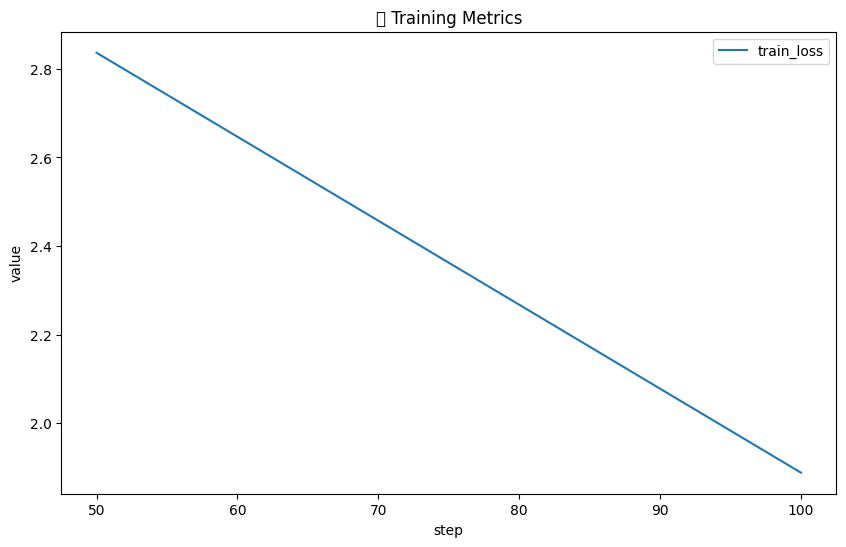


🧪 اختبار النموذج على عينة...
🤖 استجابة النموذج:    /user>   "Mickely    '6 "....


In [17]:
# ============= 12. التدريب - معدل =============
import os
import json
import torch
import gc
from pathlib import Path

# تعطيل accelerate DataLoader
import os
os.environ["ACCELERATE_DISABLE_RICH"] = "1"

# تنظيف الذاكرة
def clean_memory():
    gc.collect()
    torch.cuda.empty_cache()

clean_memory()

# إعداد Trainer المصحح
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,  
    eval_dataset=eval_tokenized,  
    data_collator=data_collator,
    compute_metrics=compute_metrics_safe,  # ✅ استخدام الدالة الصحيحة
)

print("🚀 بدء (أو استئناف) التدريب...")

# التحقق من وجود Checkpoint سابق
checkpoint_dir = "./nutrition_chatbot_v2"
last_checkpoint = None
if os.path.isdir(checkpoint_dir):
    checkpoints = list(Path(checkpoint_dir).glob("checkpoint-*"))
    if checkpoints:
        # اختيار آخر checkpoint حسب الرقم
        last_checkpoint = str(sorted(checkpoints, key=lambda x: int(x.name.split('-')[-1]))[-1])
        print(f"🔁 سيتم استئناف التدريب من {last_checkpoint}")

try:
    # إذا كان هناك checkpoint، يتم استئناف التدريب عوض البدء من الصفر
    train_result = trainer.train(resume_from_checkpoint=last_checkpoint)

    print("✅ انتهى التدريب بنجاح!")
    print(f"📊 الخسارة النهائية: {train_result.training_loss:.4f}")

    # حفظ النموذج النهائي
    output_dir = "./nutrition_chatbot_final"
    print(f"💾 جاري حفظ النموذج في {output_dir}...")
    
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    # حفظ معلمات التدريب
    training_info = {
        "training_loss": train_result.training_loss,
        "global_step": trainer.state.global_step,
        "epoch": trainer.state.epoch,
        "metrics": trainer.state.log_history[-1] if trainer.state.log_history else {}
    }
    
    with open(os.path.join(output_dir, "training_info.json"), "w") as f:
        json.dump(training_info, f, indent=2)
    
    print(f"✅ تم الحفظ بنجاح في: {output_dir}")
    
    # رسم منحنيات التدريب
    import matplotlib.pyplot as plt

    history = trainer.state.log_history
    steps = [h["step"] for h in history if "step" in h and "loss" in h]
    losses = [h["loss"] for h in history if "step" in h and "loss" in h]
    eval_steps = [h["step"] for h in history if "step" in h and ("eval_rouge1" in h or "eval_accuracy" in h)]
    eval_rouge1 = [h.get("eval_rouge1") for h in history if "eval_rouge1" in h]
    eval_acc = [h.get("eval_accuracy") for h in history if "eval_accuracy" in h]

    plt.figure(figsize=(10,6))
    plt.plot(steps, losses, label="train_loss")
    if eval_rouge1:
        plt.plot(eval_steps, eval_rouge1, label="eval_rouge1")
    if eval_acc:
        plt.plot(eval_steps, eval_acc, label="eval_accuracy")
    plt.xlabel("step")
    plt.ylabel("value")
    plt.legend()
    plt.title("📈 Training Metrics")
    plt.show()
    
    # اختبار النموذج على عينة
    print("\n🧪 اختبار النموذج على عينة...")
    test_input = "<system>أنت خبير تغذية محترف.</system>\n<user>أريد وجبة صحية منخفضة السعرات</user>"
    
    inputs = tokenizer(test_input, return_tensors="pt", truncation=True, max_length=1024)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1000,
            temperature=0.7,
            do_sample=True
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"🤖 استجابة النموذج: {response[:200]}...")

except Exception as e:
    print(f"❌ حدث خطأ: {e}")
    import traceback
    traceback.print_exc()

In [ ]:



# ============= اختبار النموذج المدرب =============
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("🔧 جاري تحميل النموذج المدرب...")

# تحميل النموذج والـ tokenizer المحفوظين
model_path = "./nutrition_chatbot_final"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# نقل النموذج إلى الجهاز المناسب
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✅ تم تحميل النموذج على {device}")

# أمثلة للاختبار
test_cases = [
    {
        "input": "<system>You are a professional nutritionist specialized in providing dietary advice.</system>\n<user>I need a meal for Weight Loss. Can you recommend something?</user>",
        "description": "توصية وجبة لفقدان الوزن"
    },
    {
        "input": "<system>You are a professional nutritionist specialized in providing dietary advice.</system>\n<user>Tell me about the nutritional value of a healthy meal</user>",
        "description": "سؤال عن القيم الغذائية"
    },
    {
        "input": "<system>You are a professional nutritionist specialized in providing dietary advice.</system>\n<user>How can I prepare a muscle building meal?</user>",
        "description": "طريقة تحضير وجبة لبناء العضلات"
    }
]

print("\n🧪 بدء الاختبارات...")

for i, test_case in enumerate(test_cases, 1):
    print(f"\n--- اختبار {i}: {test_case['description']} ---")
    print(f"📝 المدخل: {test_case['input']}")

    # Tokenization
    inputs = tokenizer(
        test_case['input'],
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)

    # توليد الاستجابة
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1000,
            temperature=0.6,
            do_sample=True,
            top_p=0.85,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            num_beams=4,
            early_stopping=True
        )

    # فك الترميز
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print(f"🤖 الاستجابة:")
    print(response)
    print("-" * 50)

print("\n✅ انتهى الاختبار!")